In [ ]:
from google.colab import files

In [ ]:
import pandas as pd

In [ ]:
uploaded = files.upload()

Saving PFDA_weather.csv to PFDA_weather (1).csv
Saving actividad_16_dayana_herrera.ipynb to actividad_16_dayana_herrera.ipynb
Saving fechas_registros.csv to fechas_registros.csv


In [ ]:
df_rides = pd.read_csv("PFDA_rides.csv")

In [ ]:
df_weather = pd.read_csv("PFDA_weather.csv")

# *1) Exploración inicial del dataset*

In [ ]:
df_rides.head(2)

,distance,cab_type,time_stamp,destination,source,price,surge_multiplier,id,product_id,name
0,0.44,Lyft,1.544950e+12,North Station,Haymarket Square,5.0,1,424553bb-7174-41ea-aeb4-fe06d4f4b9d7,lyft_line,Shared
1,0.44,Lyft,1.544950e+12,North Station,Haymarket Square,11.0,1,4bd23055-6827-41c6-b23b-3c491f24e74d,lyft_premier,Lux


In [ ]:
df_weather.head(2)

,temp,location,clouds,pressure,rain,time_stamp,humidity,wind
0,42.42,Back Bay,1.0,1012.14,0.1228,1545003901,0.77,11.25
1,42.43,Beacon Hill,1.0,1012.15,0.1846,1545003901,0.76,11.32


In [ ]:
df_rides.shape

(693071, 10)

In [ ]:
df_weather.shape

(6276, 8)

In [ ]:
df_weather.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6276 entries, 0 to 6275
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   temp        6276 non-null   float64
 1   location    6276 non-null   object 
 2   clouds      6276 non-null   float64
 3   pressure    6276 non-null   float64
 4   rain        894 non-null    float64
 5   time_stamp  6276 non-null   int64  
 6   humidity    6276 non-null   float64
 7   wind        6276 non-null   float64
dtypes: float64(6), int64(1), object(1)
memory usage: 392.4+ KB


In [ ]:
df_rides.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 693071 entries, 0 to 693070
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   distance          693071 non-null  float64
 1   cab_type          693071 non-null  object 
 2   time_stamp        693071 non-null  float64
 3   destination       693071 non-null  object 
 4   source            693071 non-null  object 
 5   price             637976 non-null  float64
 6   surge_multiplier  693071 non-null  int64  
 7   id                693071 non-null  object 
 8   product_id        693071 non-null  object 
 9   name              693071 non-null  object 
dtypes: float64(3), int64(1), object(6)
memory usage: 52.9+ MB


In [ ]:
df_rides.dtypes

,0
distance,float64
cab_type,object
time_stamp,float64
destination,object
source,object
price,float64
surge_multiplier,int64
id,object
product_id,object
name,object


In [ ]:
df_weather.dtypes

,0
temp,float64
location,object
clouds,float64
pressure,float64
rain,float64
time_stamp,int64
humidity,float64
wind,float64


## ***2) Evaluación de calidad de datos***





In [ ]:
# conteo de valores faltantes por columnas

In [ ]:
# columnas con valores faltantes o nulos

In [ ]:
df_weather.isna().sum(axis=0)

,0
temp,0
location,0
clouds,0
pressure,0
rain,5382
time_stamp,0
humidity,0
wind,0


La columna rain dento del dataset weather tiene un porcentaje de filas vacias o nulas de alrededor del 85.8%, por lo que, lo que se podría realizar es una limieza de los datos, imputando esos valores nulos por valores de 0, lo que daría a indicar la ausencia de precipitación o que no hubo lluvia.

In [ ]:
df_rides.isna().sum(axis=0)

,0
distance,0
cab_type,0
time_stamp,0
destination,0
source,0
price,55095
surge_multiplier,0
id,0
product_id,0
name,0


La columna price del dataset rides tiene un porcenaje del 7.95% de valores flatantes/nulos, casi un 8% del total de los datos. Esta columna al ser la variable bjetivo principal si tiene un error o valor faltante va a tener un impacto más serio que las demás variables, por lo que si decidimos eliminar las filas, se perderá información relevante, ya que estariamos perdiendo la información de 55095 viajes, lo que reduciría ligeramente el poder predictivo si la muestra original fuera más pequeña, aunque en este caso podría ser aceptable ya que hay casi 700000 filas. Sin embargo, otra opción que podriamos considerar es rellenar o imputar los valores faltantes con el precio promedio o la mediana de todos los viajes, como lo veamos más conveniente

**Registros duplicados**

In [ ]:
df_rides.duplicated().sum()

np.int64(0)

In [ ]:
df_weather.duplicated().sum()

np.int64(0)

In [ ]:
#Outliers

In [ ]:
percentiles = [0.25, 0.75, 0.95, 0.99]

In [ ]:
df_rides[['price', 'distance', 'surge_multiplier', 'time_stamp']].describe(percentiles=percentiles)

,price,distance,surge_multiplier,time_stamp
count,637976.000000,693071.000000,693071.000000,6.930710e+05
mean,16.545125,2.189430,1.014287,1.544046e+12
std,9.324359,1.138937,0.118818,6.892342e+08
min,2.500000,0.020000,1.000000,1.543200e+12
25%,9.000000,1.280000,1.000000,1.543440e+12
50%,13.500000,2.160000,1.000000,1.543740e+12
75%,22.500000,2.920000,1.000000,1.544830e+12
95%,34.000000,4.460000,1.000000,1.545090e+12
99%,42.500000,5.560000,2.000000,1.545150e+12
max,97.500000,7.860000,3.000000,1.545160e+12


In [ ]:
df_weather[['rain', 'temp', 'clouds', 'pressure', 'humidity', 'wind', 'time_stamp']].describe(percentiles=percentiles)

,rain,temp,clouds,pressure,humidity,wind,time_stamp
count,894.000000,6276.000000,6276.000000,6276.000000,6276.000000,6276.000000,6.276000e+03
mean,0.057652,39.090475,0.677777,1008.445209,0.763985,6.802812,1.543857e+09
std,0.100758,6.022055,0.314284,12.870775,0.127340,3.633466,6.659340e+05
min,0.000200,19.620000,0.000000,988.250000,0.450000,0.290000,1.543204e+09
25%,0.004900,36.077500,0.440000,997.747500,0.670000,3.517500,1.543387e+09
50%,0.014850,40.130000,0.780000,1007.660000,0.760000,6.570000,1.543514e+09
75%,0.060925,42.832500,0.970000,1018.480000,0.890000,9.920000,1.544691e+09
95%,0.220335,47.367500,1.000000,1033.360000,0.940000,12.072500,1.545065e+09
99%,0.570835,52.147500,1.000000,1034.902500,0.960000,15.555000,1.545141e+09
max,0.780700,55.410000,1.000000,1035.120000,0.990000,18.180000,1.545159e+09


***Outliers para la columna price del dataset rides***

In [ ]:
q1= df_rides["price"].quantile(0.25)
q3 = df_rides['price'].quantile(0.75)

IQR = q3-q1
limite_inferior_pr = q1 - 1.5*IQR
limite_superior_pr = q3 + 1.5*IQR

In [ ]:
print(limite_inferior_pr)
print(limite_superior_pr)

-11.25
42.75


In [ ]:
outliers_price = df_rides[(df_rides["price"]>limite_superior_pr)|(df_rides["price"]<limite_inferior_pr)]

In [ ]:
outliers_price

,distance,cab_type,time_stamp,destination,source,price,surge_multiplier,id,product_id,name
706,3.25,Lyft,1.543730e+12,Back Bay,South Station,52.5,2,6c187b77-cfab-4fc2-87ae-ce6caf756e35,lyft_lux,Lux Black
707,3.25,Lyft,1.543730e+12,Back Bay,South Station,67.5,2,77644bac-cb00-4368-8aef-a3d0fd7861c2,lyft_luxsuv,Lux Black XL
769,4.76,Lyft,1.543280e+12,Boston University,Theatre District,45.5,1,8e4bd9d1-d823-4f20-8dca-42d22da91002,lyft_luxsuv,Lux Black XL
1094,4.31,Lyft,1.544920e+12,Fenway,Theatre District,45.5,1,3bebdd9d-17d7-47e0-9d92-2a08a56693d3,lyft_luxsuv,Lux Black XL
1318,5.33,Lyft,1.545080e+12,Boston University,Financial District,45.5,1,91182a5d-dc85-4870-acb3-bc31604d15ab,lyft_luxsuv,Lux Black XL
...,...,...,...,...,...,...,...,...,...,...
692439,5.56,Uber,1.543450e+12,Boston University,Financial District,47.0,1,ec85457f-b575-42a8-8ff7-8bdf2ee666a8,6d318bcc-22a3-4af6-bddd-b409bfce1546,Black SUV
692698,4.58,Lyft,1.543300e+12,Fenway,Financial District,52.5,1,1d2bc447-5fcf-4fa0-a4fc-5838e07abeff,lyft_luxsuv,Lux Black XL
692891,5.42,Lyft,1.543570e+12,Boston University,Financial District,47.5,1,f10c8d27-d2c9-4e16-9762-1d35fdd56561,lyft_luxsuv,Lux Black XL
692962,7.36,Uber,1.543510e+12,North End,Back Bay,51.0,1,006c270a-bfa8-450f-9628-2d6667e55560,6d318bcc-22a3-4af6-bddd-b409bfce1546,Black SUV


El porcentaje de outliers que existe para la columna price es de 0.88%  del total de los valores. Un porcentaje muy bajo nos confirma que estos son eventos muy raros y representan los viajes más caros. Como tienen son un bajo porcentaje de todos los datos, el riesgo a que sesguen severamente la media es bajo, pero si sumimos que no hay outliers o los ignorásemos por el hecho de que son pocos datos, existe un alto riesgo de que haya sesgo si se trata de un modelo de regresión lineal.
Dado que representan menos del 1% de los datos y son los viajes que generan mayor ganancia potencial, eliminar los 5,589 registros sería una pérdida de información valiosa sobre el comportamiento extremo del mercado.

***Outliers para la columna distance del dataset rides***

In [ ]:
q1= df_rides["distance"].quantile(0.25)
q3 = df_rides["distance"].quantile(0.75)

IQR = q3-q1
limite_inferior_d = q1 - 1.5*IQR
limite_superior_d = q3 + 1.5*IQR

In [ ]:
print(limite_inferior_d)
print(limite_superior_d)

-1.18
5.38


In [ ]:
outliers_distance = df_rides[(df_rides["distance"]>limite_superior_d)|(df_rides["distance"]<limite_inferior_d)]

In [ ]:
outliers_distance

,distance,cab_type,time_stamp,destination,source,price,surge_multiplier,id,product_id,name
515,7.46,Uber,1.544700e+12,Northeastern University,Financial District,NaN,1,797848bb-3e80-41a2-a997-ffdc294530eb,8cf7e821-f0d3-49c6-8eba-e679c0ebcf6a,Taxi
516,7.46,Uber,1.544700e+12,Northeastern University,Financial District,16.0,1,eeae82c8-83e0-44e8-bf70-8e5eb8fb83e4,9a0e7b09-b92b-4c41-9779-2ad22b4d779d,WAV
1977,5.56,Uber,1.543850e+12,Boston University,Financial District,12.5,1,4346c8f4-c5f8-40b3-9e08-24104f0719ef,997acbb5-e102-41e1-b155-9df7de0a73f2,UberPool
1978,5.56,Uber,1.543850e+12,Boston University,Financial District,15.0,1,4e9681fe-f88b-42d5-9fc1-5d2282846777,9a0e7b09-b92b-4c41-9779-2ad22b4d779d,WAV
1979,5.56,Uber,1.543850e+12,Boston University,Financial District,15.0,1,75d0f44f-3985-467d-a8a4-1df97c2e8d25,55c66225-fbe7-4fd5-9072-eab1ece5e23e,UberX
...,...,...,...,...,...,...,...,...,...,...
693005,7.36,Uber,1.543510e+12,North End,Back Bay,14.5,1,1d31ef5f-2637-46e0-93cf-8d0fe3073b17,997acbb5-e102-41e1-b155-9df7de0a73f2,UberPool
693006,7.36,Uber,1.543510e+12,North End,Back Bay,36.0,1,39544c00-20c2-4a8c-9248-5818d37c4af9,6c84fd89-3f11-4782-9b50-97c468b19529,Black
693007,7.36,Uber,1.543510e+12,North End,Back Bay,49.5,1,c12672b4-2a17-422a-a72f-815d4ed75281,6d318bcc-22a3-4af6-bddd-b409bfce1546,Black SUV
693008,7.36,Uber,1.543510e+12,North End,Back Bay,16.0,1,c20c7f8f-036c-41ec-9f08-dd19576cc324,55c66225-fbe7-4fd5-9072-eab1ece5e23e,UberX


Los valores para la columna distance que son superiores a 5.38 millas, son considerados outliers altos y respresentan el 1.36% de los datos totales, es decir que estos son los trayectos más largos dentro del dataset, estos altos valores representan un incremento en la columna de precio, puesto que estos outliers mientras más altos sean, influenciarán en un precio base mucho mayor. Siendo una de las principales causas de los precios altos.

***Outliers para la columna surge_multiplier del dataset rides***

In [ ]:
q1= df_rides["surge_multiplier"].quantile(0.25)
q3 = df_rides["surge_multiplier"].quantile(0.75)

IQR = q3-q1
limite_inferior_sg = q1 - 1.5*IQR
limite_superior_sg = q3 + 1.5*IQR

In [ ]:
print(limite_superior_sg)
print(limite_inferior_sg)

1.0
1.0


In [ ]:
outliers_surge = df_rides[(df_rides["surge_multiplier"]>limite_superior_sg)|(df_rides["surge_multiplier"]<limite_inferior_sg)]

In [ ]:
outliers_surge

,distance,cab_type,time_stamp,destination,source,price,surge_multiplier,id,product_id,name
705,3.25,Lyft,1.543730e+12,Back Bay,South Station,42.5,2,46c02b41-6f51-43ab-a389-21d704cac2db,lyft_plus,Lyft XL
706,3.25,Lyft,1.543730e+12,Back Bay,South Station,52.5,2,6c187b77-cfab-4fc2-87ae-ce6caf756e35,lyft_lux,Lux Black
707,3.25,Lyft,1.543730e+12,Back Bay,South Station,67.5,2,77644bac-cb00-4368-8aef-a3d0fd7861c2,lyft_luxsuv,Lux Black XL
708,3.25,Lyft,1.543730e+12,Back Bay,South Station,38.0,2,78695f94-063c-4ea0-9c5d-66b8a0d67f01,lyft_premier,Lux
709,3.25,Lyft,1.543730e+12,Back Bay,South Station,22.5,2,9c5c0e40-a5b9-4866-a77b-f4e9bf7eee84,lyft,Lyft
...,...,...,...,...,...,...,...,...,...,...
692257,3.00,Lyft,1.544760e+12,North End,Back Bay,22.5,2,1b52c270-f898-45ce-b001-0df6834b3319,lyft,Lyft
692258,3.00,Lyft,1.544760e+12,North End,Back Bay,38.5,2,2124e2c4-bafa-4953-b280-038ff12c2f6c,lyft_premier,Lux
692259,3.00,Lyft,1.544760e+12,North End,Back Bay,55.0,2,8a0d1d10-8458-4bc2-942f-9249d2acdd7f,lyft_lux,Lux Black
692260,3.00,Lyft,1.544760e+12,North End,Back Bay,65.0,2,c63e12f6-24b7-47f8-a8c1-f0a9cdac32bc,lyft_luxsuv,Lux Black XL


Solo el 1.55% de los viajes en el dataset tuvieron activa la tarifa dinámica, lo que confirma que el surge_multiplier es una variable de evento rara y valiosa.
Los 9,890 outliers de surge_multiplier son la causa principal de los outliers de price. La distribución de price se vuelve altamente sesgada porque el 1.55% de los viajes se duplican o triplican artificialmente en precio. Esta variable es una de las más importante para explicar los altos precios.

***Outliers para la columna distance del dataset weather***

In [ ]:
q1= df_weather["rain"].quantile(0.25)
q3 = df_weather["rain"].quantile(0.75)

IQR = q3-q1
limite_inferior_r = q1 - 1.5*IQR
limite_superior_r = q3 + 1.5*IQR

In [ ]:
print(limite_inferior_r)
print(limite_superior_r)

-0.0791375
0.1449625


In [ ]:
outliers_rain = df_weather[(df_weather["rain"]>limite_superior_r)|(df_weather["rain"]<limite_inferior_r)]

In [ ]:
outliers_rain

,temp,location,clouds,pressure,rain,time_stamp,humidity,wind
1,42.43,Beacon Hill,1.00,1012.15,0.1846,1545003901,0.76,11.32
4,43.13,Financial District,1.00,1012.14,0.1786,1545003901,0.75,11.49
5,42.34,Haymarket Square,1.00,1012.15,0.2068,1545003901,0.77,11.49
6,42.36,North End,1.00,1012.15,0.2088,1545003901,0.77,11.46
7,42.21,North Station,1.00,1012.16,0.2069,1545003901,0.77,11.37
...,...,...,...,...,...,...,...,...
5432,43.88,Northeastern University,0.99,1005.30,0.1672,1543281441,0.91,11.11
5433,44.82,South Station,0.99,1005.37,0.2591,1543281441,0.88,11.29
5434,43.98,Theatre District,0.99,1005.36,0.2353,1543281441,0.90,11.24
5435,44.01,West End,0.99,1005.39,0.2724,1543281441,0.90,11.24


In [ ]:
q1= df_weather["temp"].quantile(0.25)
q3 = df_weather["temp"].quantile(0.75)

IQR = q3-q1
limite_inferior_t = q1 - 1.5*IQR
limite_superior_t = q3 + 1.5*IQR
print(limite_inferior_t)
print(limite_superior_t)

25.945000000000007
52.96499999999999


In [ ]:
outliers_temp = df_weather[(df_weather["temp"]>limite_superior_t)|(df_weather["temp"]<limite_inferior_t)]
outliers_temp

,temp,location,clouds,pressure,rain,time_stamp,humidity,wind
134,25.40,Back Bay,0.76,1006.33,NaN,1545129901,0.52,17.96
135,25.70,Beacon Hill,0.80,1006.69,NaN,1545129901,0.53,17.88
136,25.50,Boston University,0.79,1006.25,NaN,1545129901,0.52,17.81
137,25.74,Financial District,0.77,1006.30,NaN,1545129901,0.52,18.11
138,25.37,Haymarket Square,0.77,1006.30,NaN,1545129901,0.53,18.16
...,...,...,...,...,...,...,...,...
6084,25.27,Haymarket Square,0.51,1009.35,NaN,1545140701,0.49,13.06
6085,25.29,North End,0.51,1009.35,NaN,1545140701,0.49,13.08
6086,25.29,North Station,0.51,1009.36,NaN,1545140701,0.49,13.04
6087,25.29,Northeastern University,0.51,1009.37,NaN,1545140701,0.49,12.89


Estos outliers encontrados en el dataset weather, las columanas relacionadas al clima, más que nada la lluvia y la temperatura, tienen importancia para el análisis, puesto que pueden coincidir casualmete con los outliers de surge_mulitiplier y price, puesto que, por condiciones atmosfericas, puede aumentar el precio y la demanda de taxis o de estos servicios de transporte, ya que estas situaciones obligan a las personas a hacer un uso más "obligado" de estos servicios, debido a las codiciones atmósfericas, sobre todo en circuntancias de lluvia.

***Analisis de distribucion de variables***

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
numericas = df_rides[["distance", "price", "surge_multiplier"]]

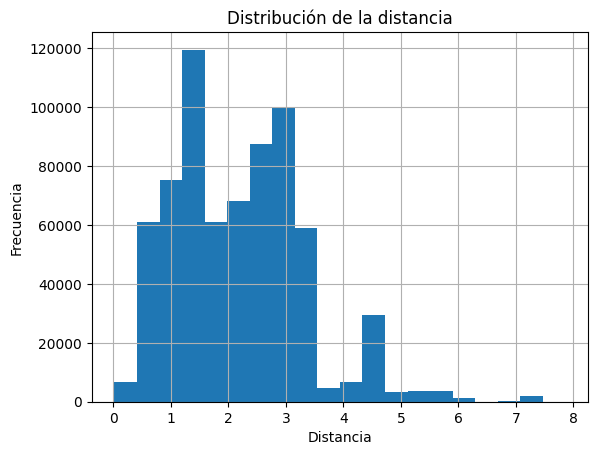

In [ ]:
numericas["distance"].hist(bins=20)
plt.title("Distribución de la distancia")
plt.xlabel("Distancia")
plt.ylabel("Frecuencia")
plt.show()

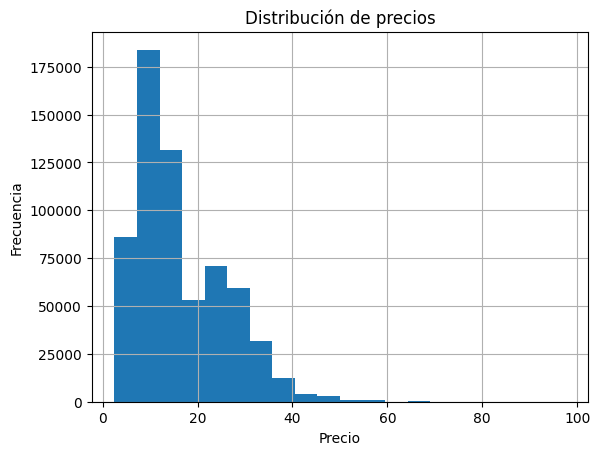

In [ ]:
numericas["price"].hist(bins=20)
plt.title("Distribución de precios")
plt.xlabel("Precio")
plt.ylabel("Frecuencia")
plt.show()

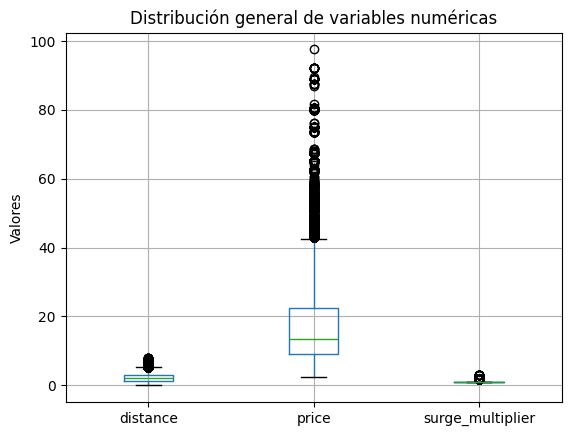

In [ ]:
numericas.boxplot()
plt.title("Distribución general de variables numéricas")
plt.ylabel("Valores")
plt.show()

Al revisar su estructura se comprobó que cuenta con una cantidad considerable de registros, lo que permite analizar de forma general el funcionamiento del servicio. Durante la evaluación de calidad se observó que no hay registros duplicados, por lo que cada viaje se encuentra almacenado una sola vez. En cuanto a los valores nulos, se identificó que únicamente la columna price presenta 55.095 registros vacíos, mientras que las demás variables están completas. Esto significa que varios viajes no tienen el precio registrado, probablemente por fallas en el sistema, cancelaciones o datos que no se guardaron correctamente. Esta ausencia de información puede influir en los análisis relacionados con precios promedios, comparación entre distancias o estudios sobre el multiplicador de tarifa, ya que reduce la precisión y representatividad de los resultados.

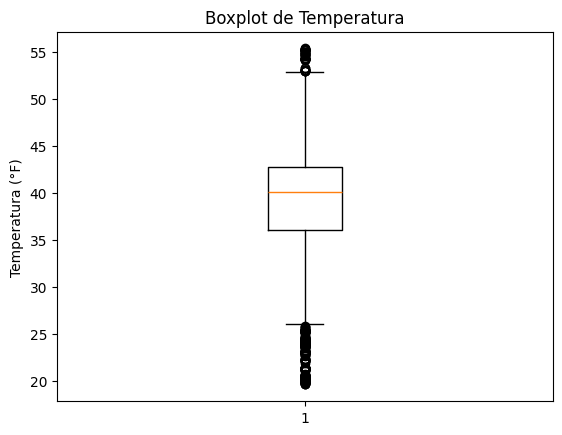

In [ ]:
plt.boxplot(df_weather["temp"].dropna())
plt.title("Boxplot de Temperatura")
plt.ylabel("Temperatura (°F)")
plt.show()

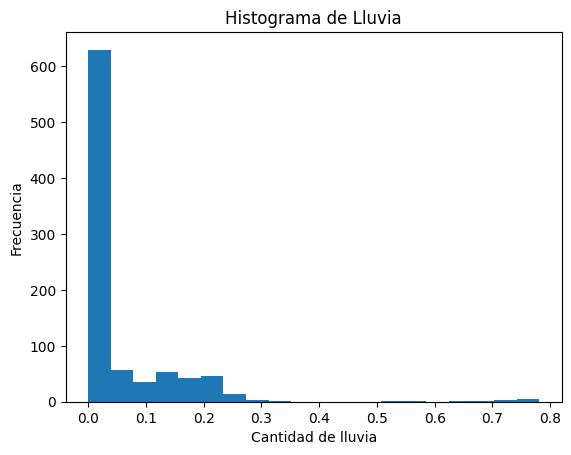

In [ ]:
plt.hist(df_weather["rain"].dropna(), bins=20)
plt.title("Histograma de Lluvia")
plt.xlabel("Cantidad de lluvia")
plt.ylabel("Frecuencia")
plt.show()

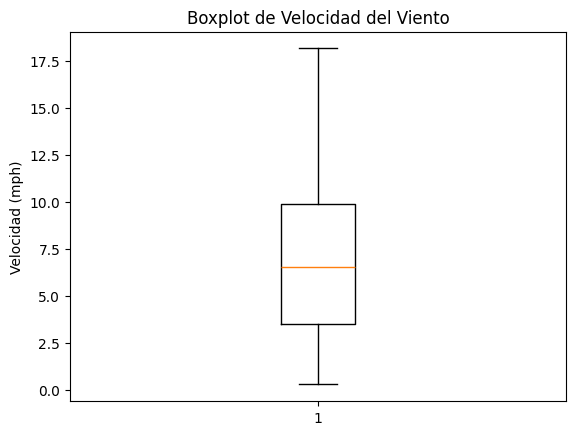

In [ ]:
plt.boxplot(df_weather["wind"].dropna())
plt.title("Boxplot de Velocidad del Viento")
plt.ylabel("Velocidad (mph)")
plt.show()

En el análisis visual del conjunto de datos del clima se observó que la temperatura presenta una distribución estable, concentrada principalmente en valores medios sin grandes variaciones, lo que indica un comportamiento regular. En cambio, la variable de lluvia mostró que la mayoría de los registros corresponden a días sin precipitaciones, mientras que existen pocos casos con valores elevados que se consideran atípicos. Finalmente, en la variable de velocidad del viento se identifican algunas fluctuaciones, aunque la mayoría de los datos se mantienen dentro de un rango moderado. Estos resultados reflejan que las condiciones climáticas tienden a ser estables, con excepciones en eventos puntuales de lluvia o viento fuerte.

***Reflexion y diagnostico general***


El análisis muestra que las condiciones climáticas influyen directamente en la cantidad de solicitudes de autos. Cuando el clima es favorable, con temperaturas templadas y ausencia de lluvia, se observa un aumento en las solicitudes, ya que las personas se sienten más motivadas a desplazarse o salir de casa. En cambio, durante días con precipitaciones intensas o temperaturas extremas, las solicitudes tienden a disminuir, posiblemente por la incomodidad o el riesgo asociado a conducir en esas condiciones. Esto evidencia que el clima actúa como un factor determinante en la demanda de servicios de transporte, afectando los patrones de uso según las variaciones meteorológicas.